# Distribution of Birth Years Over Time

This notebook provides an analysis of the distribution of birth years over time for the selected population and identifies different generations.

It also highlights changes in gender distribution over time.

Regarding the **Pandas library**, take ten minutes to discover this library with this warm up **tutorial [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)**


In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

In [2]:
    import warnings
    warnings.filterwarnings('ignore')


## Import the data

The data is available in the da1_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [3]:
## create variable declaring the path to the data
path_to_data = 'da1_data/archeologists_gender_birthyear.csv'

In [6]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)

## first rows of the dataframe
df_p.head()

,archaeologist,gender,birthDate,archaeologistLabel,genderLabel
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male
2,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q6581097,1924,Géza Ferenczi,male
3,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q6581097,1900,Nándor Fettich,male
4,http://www.wikidata.org/entity/Q100139704,http://www.wikidata.org/entity/Q6581072,1919,Andrée Piboule,female


In [5]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32693 entries, 0 to 32692
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   s          32693 non-null  object
 1   label      32693 non-null  object
 2   birthDate  32693 non-null  int64 
 3   genLabel   32693 non-null  object
dtypes: int64(1), object(3)
memory usage: 1021.8+ KB


In [7]:
### Rename a column
df_p = df_p.rename(columns={'birthDate': 'birthYear'})

In [8]:
### Select the first values of this column
df_p.birthYear.head()

0    1837
1    1912
2    1924
3    1900
4    1919
Name: birthYear, dtype: int64

### Add a column to the DataFrame containing the gender code

In [13]:
### First, we create a function that performs the intended task

## The argument of the ‘code_gender’ function is a name of your choice
# It is then referenced within the function as a variable
# and holds the value entered when the function is called

def code_gender(genderLabel):
    if genderLabel == 'male':
        # genre masculin
        a = 'M'
    elif genderLabel =='female':
        # genre féminin
        a = 'F'
    else:
        # genre autre
        a = 'A'
    return a    

In [14]:
### We test if the function works
print(code_gender('female'))

F


In [15]:
### Add a new column and enter the result of the function in each row
df_p['genCode'] = df_p.apply(lambda x: code_gender(x['genderLabel']), axis=1)

In [16]:
### We examine the first five rows that have the value ‘A’ = other
df_p[df_p['genCode']=='A'][:5]

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode


In [17]:
### Group by gender and count  
df_p.groupby("genCode").size()   # .reset_index(name="count")

genCode
F     4435
M    15447
dtype: int64

## Effectifs par année

In [18]:
### We inspect the values in the ‘birthYear’ column 
# and check what the data type is
df_p['birthYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 19882 entries, 0 to 19881
Series name: birthYear
Non-Null Count  Dtype
--------------  -----
19882 non-null  int64
dtypes: int64(1)
memory usage: 155.5 KB


In [19]:
### If it's an integer (int64) there's nothig to do 
# Otherwise, we change the data type of the BirthYear column
# from 'object' (text) to 'integer'
df_p['birthYear'] = df_p['birthYear'].astype(int)

In [20]:
### On regroupe les données par année et on compte le nombre de naissances par année
# On créé un nouveau DataFrame comme résultat
years_count = pd.DataFrame(df_p.groupby('birthYear').size()).reset_index()
years_count.columns=['year','number']
years_count

,year,number
0,1701,2
1,1702,3
2,1703,1
3,1704,2
4,1705,2
...,...,...
294,1996,3
295,1997,5
296,1998,1
297,1999,1


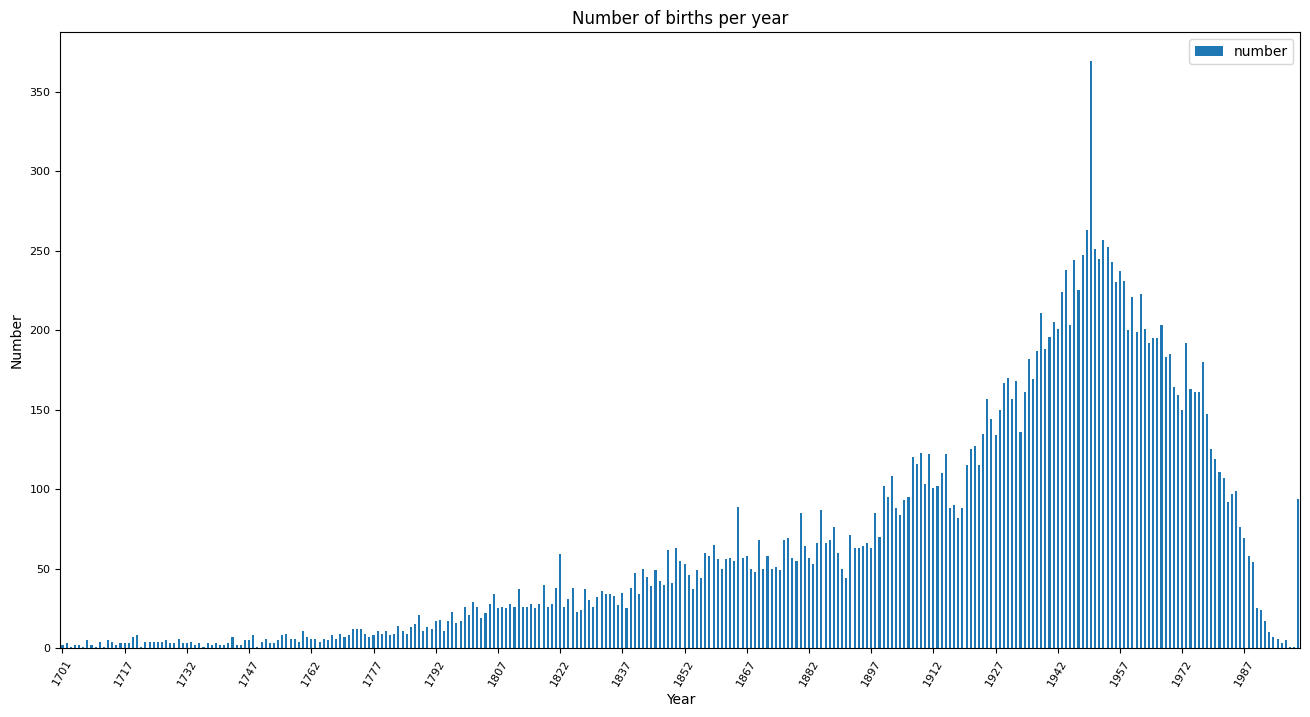

In [21]:
### Représentation graphique des effectifs par année

ax = years_count.plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year')
plt.show()

### Issue if years are missing

We delete some years here, although available in reality, in order to illustrate the bias and the solution

In [22]:
## Apparently all years are available with some number of persons born
# But what would happen if a year is missing
missing_years = pd.Index(range(years_count['year'].min(), years_count['year'].max() + 1)).difference(years_count['year']).tolist()
print(missing_years)  # Output: [1902, 1904]

[1714]


In [18]:
### We randomly delete some years as if there were no births that year
# years_count = years_count[~years_count['number'].isin([10,20,30, 40, 50])]

If you create again the plot above, no year appears to be missing

In [23]:
df_y = pd.DataFrame({'year':range(years_count['year'].min(), years_count['year'].max() + 1)})
df_y.head()

,year
0,1701
1,1702
2,1703
3,1704
4,1705


In [25]:
merged = df_y.merge(years_count, on='year', how='left')

In [26]:
merged.head(10)

,year,number
0,1701,2.0
1,1702,3.0
2,1703,1.0
3,1704,2.0
4,1705,2.0
5,1706,1.0
6,1707,5.0
7,1708,2.0
8,1709,1.0
9,1710,4.0


In [27]:
merged['number'] = merged[['number']].fillna(0)

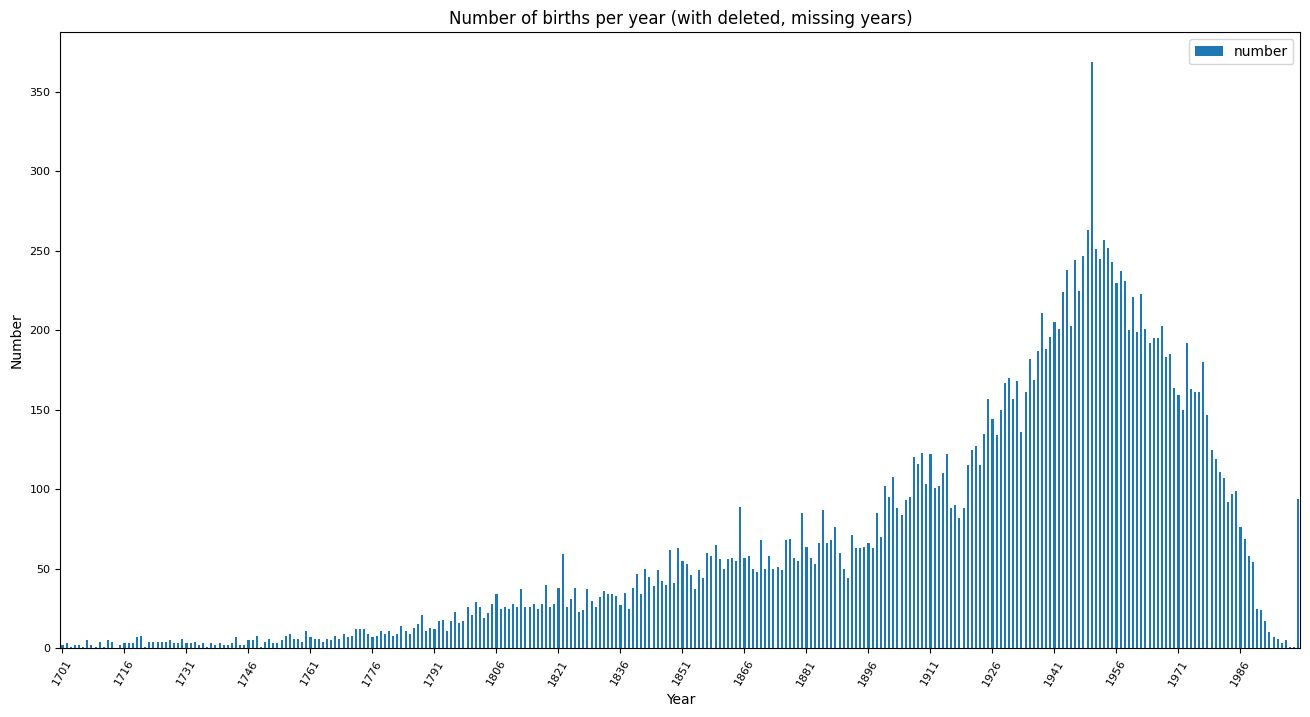

In [29]:
### Représentation graphique des effectifs par année

ax = merged[merged.year < 2001].plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year (with deleted, missing years)')
plt.show()

## Group births by 20-year periods

In [30]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
cdf_p = df_p.copy(deep=True)

In [31]:
cdf_p.head(3)

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male,M
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male,M
2,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q6581097,1924,Géza Ferenczi,male,M


In [32]:
### Année minimale et maximale dans la population
print(min(cdf_p['birthYear']), max(cdf_p['birthYear']))

1701 2000


### Codage par période de vingt ans

In [33]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1701, 2001, 20))
print(l_20[:5],l_20[-5:])

[1701, 1721, 1741, 1761, 1781] [1901, 1921, 1941, 1961, 1981]


In [34]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['birthYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode,periodes
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male,M,1821-1840
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male,M,1901-1920
2,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q6581097,1924,Géza Ferenczi,male,M,1921-1940


In [35]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1701-1720      59
1721-1740      64
1741-1760     100
1761-1780     163
1781-1800     302
1801-1820     552
1821-1840     673
1841-1860     988
1861-1880    1180
1881-1900    1338
1901-1920    2045
1921-1940    3179
1941-1960    4786
1961-1980    3497
dtype: int64

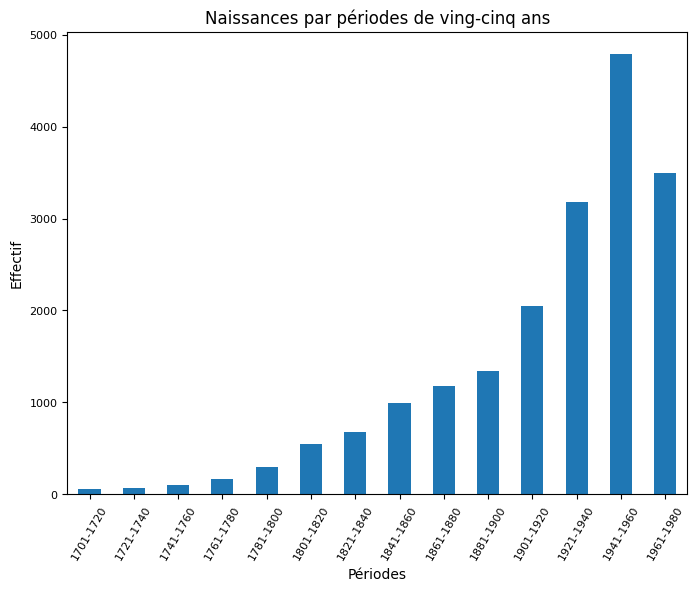

In [36]:
fig, ax = plt.subplots(figsize=(8,6))
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8)
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Naissances par périodes de ving-cinq ans')

plt.show()

## Shift to activity date

In [37]:
### Add a new column and enter the result of the function in each row
cdf_p['activityYear'] = cdf_p.apply(lambda x: x['birthYear']+45, axis=1)

In [38]:
cdf_p.head(2)

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode,periodes,activityYear
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male,M,1821-1840,1882
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male,M,1901-1920,1957


In [40]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1701+45, 2001+45, 20))
print(l_20[:5],l_20[-5:])

[1746, 1766, 1786, 1806, 1826] [1946, 1966, 1986, 2006, 2026]


In [41]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['activityYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode,periodes,activityYear
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male,M,1866-1885,1882
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male,M,1946-1965,1957
2,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q6581097,1924,Géza Ferenczi,male,M,1966-1985,1969


In [42]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1746-1765      59
1766-1785      64
1786-1805     100
1806-1825     163
1826-1845     302
1846-1865     552
1866-1885     673
1886-1905     988
1906-1925    1180
1926-1945    1338
1946-1965    2045
1966-1985    3179
1986-2005    4786
2006-2025    3497
dtype: int64

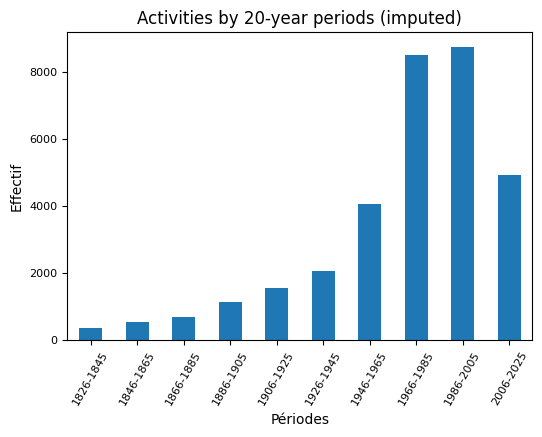

In [36]:
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8, figsize=(6, 4))
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Activities by 20-year periods (imputed)')
plt.show()

## Ajouter la représentation des genres

Only female and male, other are omitted because their number is too small for a representation.

They should be inspected separately.



In [43]:
### Regrouper et compter avec un fitre sur le genre masculin
gender_m = pd.DataFrame(cdf_p[cdf_p.genCode == 'M'].groupby('periodes', observed=False).size())
gender_m.columns = ['m']
gender_m.tail()


,m
periodes,
1926-1945,1184
1946-1965,1698
1966-1985,2455
1986-2005,3364
2006-2025,2212


In [44]:
### Regrouper et compter avec un fitre sur le genre féminin
gender_f = pd.DataFrame(cdf_p[cdf_p.genCode == 'F'].groupby('periodes').size())
gender_f.columns = ['f']
gender_f.tail()


,f
periodes,
1926-1945,154
1946-1965,347
1966-1985,724
1986-2005,1422
2006-2025,1285


In [45]:
### Fusionner les deux tableaux en utilisant l'index comme clé de jointure
merged = pd.merge(gender_m, gender_f, left_index=True, right_index=True)
merged.tail()

,m,f
periodes,,
1926-1945,1184,154
1946-1965,1698,347
1966-1985,2455,724
1986-2005,3364,1422
2006-2025,2212,1285


In [46]:
### Transformer l'index de séquence à chaîne de caractères
# ce qui est indispensable pour l'affichage dans un graphique
merged.index = merged.index.map(str)
merged.tail()

,m,f
periodes,,
1926-1945,1184,154
1946-1965,1698,347
1966-1985,2455,724
1986-2005,3364,1422
2006-2025,2212,1285


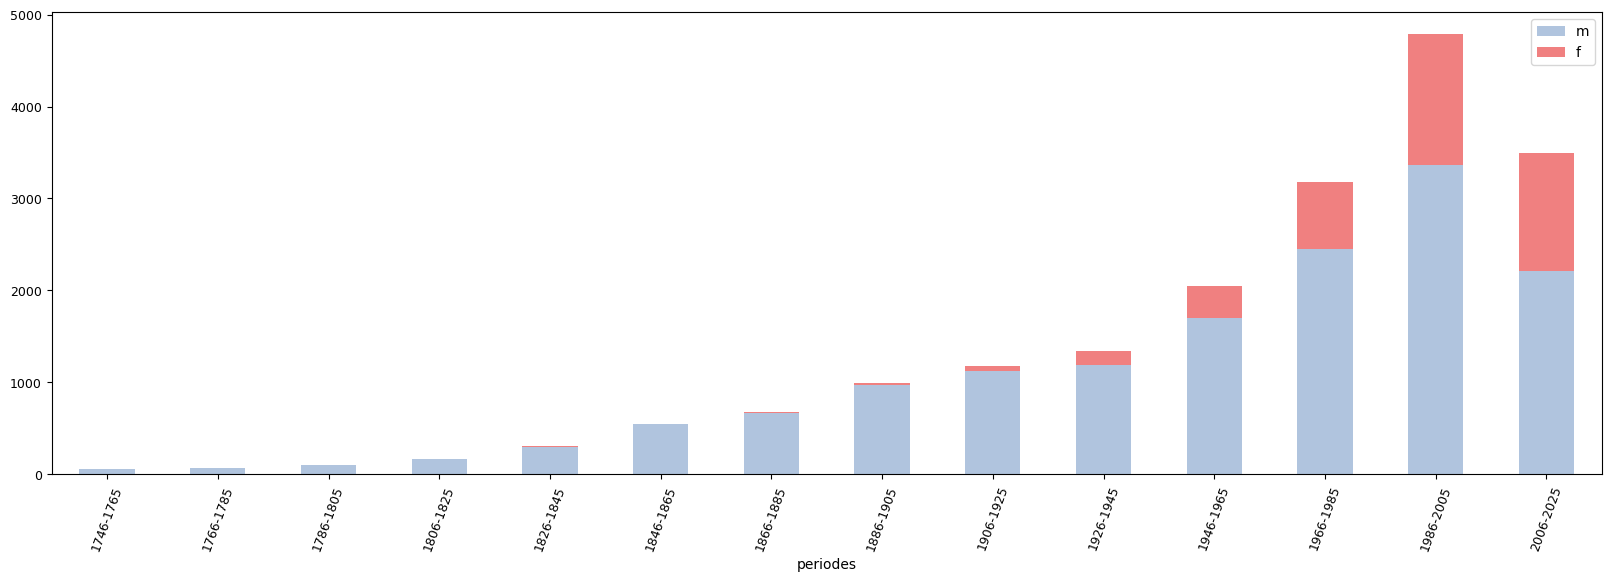

In [47]:
### Documentation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
ax = merged.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(20,6), color=['LightSteelBlue', 'LightCoral'])
plt.show()

### Coding of imputed activity dates by ten-year period

Comme on voit bien dans le graphique précédent qu'il y a deux périodes avec des effectifs radicalements différents, 
on restraint la période analysée à l'époque contemporaine et on affine avec un découpage par périodes de dix ans 

In [48]:
l_10 = list(range(1781+45, 1991+45, 10))
print(l_10[:5],l_10[-5:])

[1826, 1836, 1846, 1856, 1866] [1986, 1996, 2006, 2016, 2026]


In [49]:
### Découpage par décennies
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

cdf_p['per_10'] = pd.cut(cdf_p['activityYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['per_10'] = cdf_p['per_10'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,archaeologist,gender,birthYear,archaeologistLabel,genderLabel,genCode,periodes,activityYear,per_10
0,http://www.wikidata.org/entity/Q100038758,http://www.wikidata.org/entity/Q6581097,1837,Louis d'Eichthal,male,M,1866-1885,1882,1876-1885
1,http://www.wikidata.org/entity/Q1000405,http://www.wikidata.org/entity/Q6581097,1912,Miguel de Ferdinandy,male,M,1946-1965,1957,1956-1965
2,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q6581097,1924,Géza Ferenczi,male,M,1966-1985,1969,1966-1975


In [50]:
### On regroupe par genre comme ci-dessus
gender_m_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'M') ].groupby('per_10').size())
gender_m_10.columns = ['m']
gender_m_10.tail()


,m
per_10,
1976-1985,1346
1986-1995,1739
1996-2005,1625
2006-2015,1290
2016-2025,922


In [51]:
### Idem
gender_f_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'F')& (cdf_p.birthYear > 1780)].groupby('per_10').size())
gender_f_10.columns = ['f']
gender_f_10.tail()


,f
per_10,
1976-1985,409
1986-1995,680
1996-2005,742
2006-2015,650
2016-2025,635


In [52]:
merged_10 = pd.merge(gender_m_10, gender_f_10, left_index=True, right_index=True)
merged_10.tail()

,m,f
per_10,,
1976-1985,1346,409
1986-1995,1739,680
1996-2005,1625,742
2006-2015,1290,650
2016-2025,922,635


In [53]:
### On transforme le type de valeur de l'index
# et on ajoute une colonne avec le total
merged_10.index = merged_10.index.map(str)
merged_10['tot']=merged_10['m']+merged_10['f']
merged_10.tail()

,m,f,tot
per_10,,,
1976-1985,1346,409,1755
1986-1995,1739,680,2419
1996-2005,1625,742,2367
2006-2015,1290,650,1940
2016-2025,922,635,1557


In [54]:
merged_10.head()

,m,f,tot
per_10,,,
1826-1835,124,0,124
1836-1845,173,5,178
1846-1855,260,2,262
1856-1865,289,1,290
1866-1875,328,4,332


In [55]:
m_10_not_zero = merged_10[merged_10.f > 0]
m_10_not_zero

,m,f,tot
per_10,,,
1836-1845,173,5,178
1846-1855,260,2,262
1856-1865,289,1,290
1866-1875,328,4,332
1876-1885,334,7,341
1886-1895,459,6,465
1896-1905,513,10,523
1906-1915,561,27,588
1916-1925,561,31,592


In [56]:
### On prépare les valeurs pour l'affichage des fréquences (proportion par rapport au total)

# liste qui contient toutes les valeurs à la suite
m_f = m_10_not_zero.m.to_list()+m_10_not_zero.f.to_list()

# liste d'égale longueur que la précédente qui contient 
# les valeurs de l'index, i.e. les périodes
tot = m_10_not_zero.tot.to_list()*2

# liste qui contient les valeurs des fréquences
lp = [round(v/t, 2) for v,t in zip(m_f, tot)]
print(lp[:3])

[0.97, 0.99, 1.0]


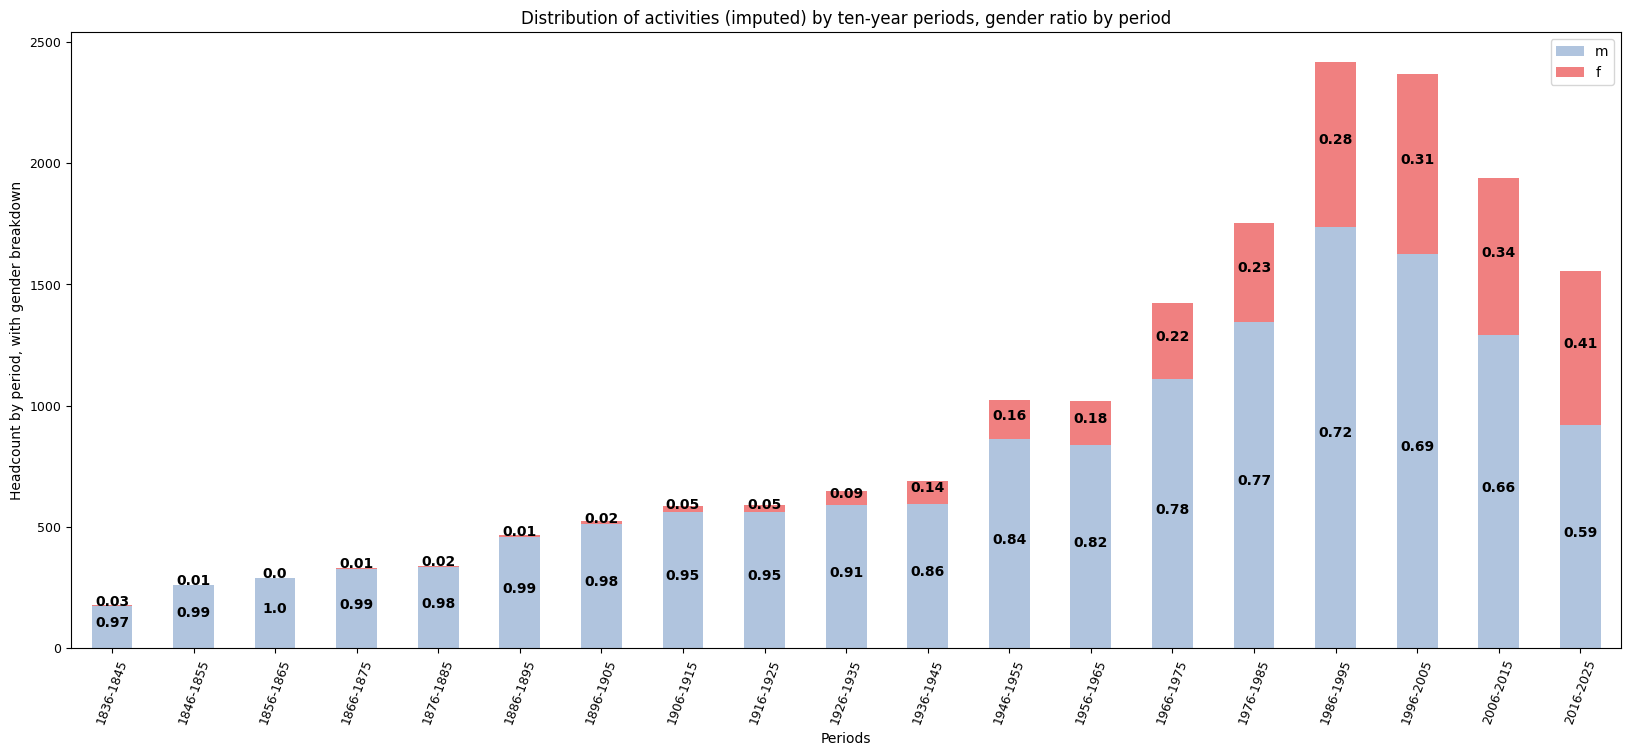

In [60]:
### Graphique avec la distribution par période et genre (M,F)
# Noter que les effectifs du genre 'Autres' étant très faibles,
# on ne les analyse pas de manière sérielle mais on peut les analyser qualitatiement

ax = m_10_not_zero.plot.bar(stacked=True, y=['m', 'f'], \
                        rot=70, fontsize=9, figsize=(20,8), color=['LightSteelBlue', 'LightCoral'])


### https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/


## On ajoute une étiquette concernant la valeur de fréquence
# à chaque rectangle dans le graphe, en utilisant la list 'lp' préparée précédemment
# Il y a autant de triangles que les valeurs d'index x le nombre de variables

for bar,v in zip(ax.patches,lp): 

    ax.text(
      # Met les étiquette aux centre des rectangles
      bar.get_x() + bar.get_width() / 2,
        
      # Ajoute les coordonnées verticales
      bar.get_height()/2 + bar.get_y(), 
      
      # Ajoute les valeurs
      v,

      # centre et met du style aux étiquettes
      ha='center',
      color='black',
      weight='bold',
      size=10
  )

plt.ylabel('Headcount by period, with gender breakdown')
plt.xlabel('Periods')
plt.title('Distribution of activities (imputed) by ten-year periods, gender ratio by period')

## On peut enregistrer l'image dans un fichier (noter le dossier créé préalablement)
# qu'on pourra ensuite introduire dans un travail et commenter

# Doc.: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
plt.savefig('da1_data/birth_distribition_10years_gender.jpg', bbox_inches='tight',
                    pad_inches=0.2)
plt.show()

### New interactive chart using Plotly 

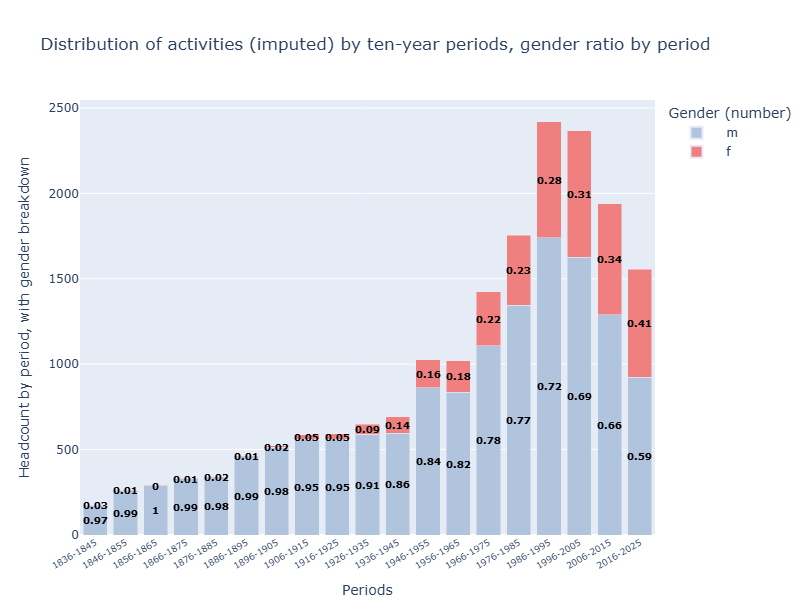

In [61]:
# Reset index to make 'per_10' a column
df_plot = m_10_not_zero.reset_index()

# Calculate percentages per period
df_plot['tot'] = df_plot['m'] + df_plot['f']
df_plot['pct_m'] = df_plot['m'] / df_plot['tot']
df_plot['pct_f'] = df_plot['f'] / df_plot['tot']

# Create stacked bar chart
fig = px.bar(
    df_plot,
    x='per_10',
    y=['m', 'f'],
    color_discrete_map={'m': 'LightSteelBlue', 'f': 'LightCoral'},
    title='Distribution of activities (imputed) by ten-year periods, gender ratio by period',
    labels={'per_10': 'Periods', 'value': 'Number', 'variable': 'Genre'},
    barmode='stack'
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=-30, tickfont=dict(size=9))

# Add percentage labels inside bars
for i, row in df_plot.iterrows():
    # Add m percentage label
    if row['m'] > 0:
        pct_m_str = f"{row['pct_m']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] / 2,
            text=pct_m_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )
    # Add f percentage label
    if row['f'] > 0:
        pct_f_str = f"{row['pct_f']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] + row['f'] / 2,
            text=pct_f_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )

# Customize hover info to show actual counts
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Number %{fullData.name}: %{y}<extra></extra>'
)

# Update layout
fig.update_layout(
    yaxis_title='Headcount by period, with gender breakdown',
    font=dict(size=12),
    width=1000,
    height=600,
    legend_title_text='Gender',
    legend=dict(
        title=dict(text="Gender (number)"),
        itemsizing='constant',
        itemwidth=50
    )
)

# Optional: Customize legend to show counts (e.g., "m (244)")
fig.for_each_trace(lambda t: t.update(name=f"{t.name}") if t.name in ['m', 'f'] else t)   # ({df_plot[t.name].iloc[0]})

# Save as interactive HTML
fig.write_html("da1_data/birth_distribition_10years_gender.html", include_plotlyjs='cdn', full_html=True)

# Optional: Show in notebook or browser
fig.show()
